Post Lab Task: Perform Classification Task on Titanic Dataset


## Task: Design, implement, and evaluate classification models on the Titanic dataset
*Dataset: Titanic Dataset*


### Subtask 1: Loading and Pre-processing the Titanic Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print("Dataset shape:", titanic_df.shape)
titanic_df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:

df = titanic_df.copy()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])
le_emb = LabelEncoder()
df['Embarked'] = le_emb.fit_transform(df['Embarked'])

print("Missing values after cleaning:\n", df.isnull().sum())
df.head()

Missing values after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### Subtask 2: Feature Scaling and Train-Test Split

In [3]:
X = df.drop(columns=['Survived'])
y = df['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 7)
Test set shape: (179, 7)


### Subtask 3: Implementing Logistic Regression

In [4]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 79.89%


### Subtask 4: Implementing Linear Discriminant Analysis (LDA)

In [5]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

lda_preds = lda_model.predict(X_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 79.33%


### Subtask 5: Implementing k-Nearest Neighbors (k-NN)

In [6]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print(f"k-NN Test Accuracy: {knn_accuracy * 100:.2f}%")

k-NN Test Accuracy: 81.01%


### Subtask 6: Implementing Gaussian Naive Bayes

In [7]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naive Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naive Bayes Test Accuracy: 78.21%


### Subtask 7: Implementing Support Vector Machine (SVM)

In [8]:
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_preds)

print(f"SVM (linear) Test Accuracy: {svm_accuracy * 100:.2f}%")

SVM (linear) Test Accuracy: 77.65%


### Subtask 8: Performance Comparison of All Classifiers

In [9]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)',
        'Gaussian Naive Bayes',
        'Support Vector Machine (linear)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100,
        nb_accuracy * 100,
        svm_accuracy * 100
    ]
})

print("--- Performance Comparison on Titanic Dataset ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison on Titanic Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          79.888268
Linear Discriminant Analysis (LDA)          79.329609
        k-Nearest Neighbors (k-NN)          81.005587
              Gaussian Naive Bayes          78.212291
   Support Vector Machine (linear)          77.653631


### Subtask 9: Confusion Matrix Heatmap

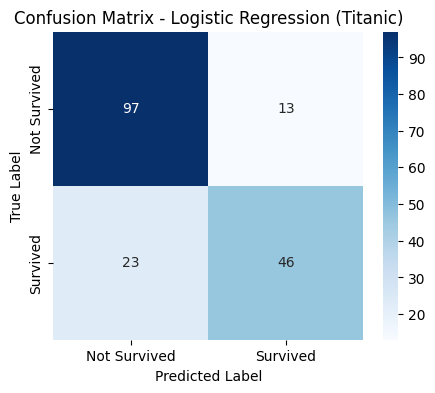

In [10]:
cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (Titanic)")
plt.show()

### Subtask 10: Precision, Recall, F1-Score, and Support Analysis

In [11]:
print("Classification Report - Logistic Regression\n")
print(classification_report(y_test, lr_preds, target_names=['Not Survived', 'Survived']))

Classification Report - Logistic Regression

              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



### Subtask 11: ROC Curve and AUC

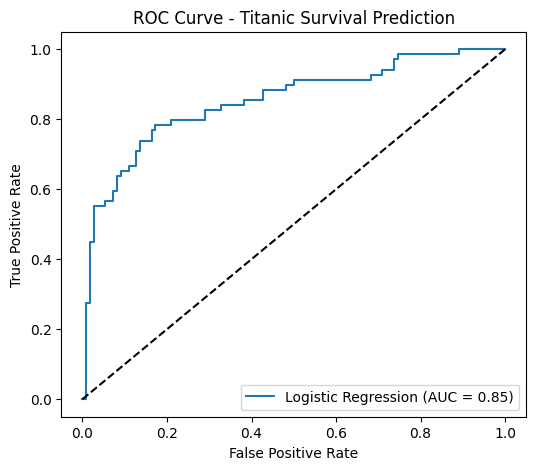

In [12]:
y_score = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Titanic Survival Prediction")
plt.legend(loc="lower right")
plt.show()

## Subtask 12: Cross Validation

In [13]:
cv_model = LogisticRegression(max_iter=500, random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Accuracy (Logistic Regression):")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy (Logistic Regression):
Fold 1: 0.7709
Fold 2: 0.7865
Fold 3: 0.7809
Fold 4: 0.7640
Fold 5: 0.8202

Mean Accuracy: 78.45%
Standard Deviation: 1.95%


Conclusion

1. Titanic is a binary classification task (Survived vs Not Survived).
2. k-NN performed best (81.01%), followed closely by Logistic Regression and LDA.
3. Naive Bayes and SVM performed slightly lower, likely due to feature correlation and the linear kernel limit.
4. The model predicts "Not Survived" better than "Survived," since more passengers died than survived.
5. A good ROC-AUC score shows the model can genuinely tell the two classes apart.
6. Cross-validation results were close to the test accuracy, confirming the model is stable and not just lucky on one split.